# Laplaciano em Grafos: Propagação de Rótulos

## Luis Gustavo Nonato  <br>
ICMC-USP

----

O problema que buscamos resolver é o seguinte:

Suponha que tenhamos um conjunto de pontos em um espaço $\mathbb{R}^n$ e que sabemos que estes pontos pertencem a $k$ classes distintas (como em um problema de classificação). Porém, a classe não é conhecida para todos os pontos, mas apenas para um subconjunto dos pontos.

O objetivo é espalhar os rótulos conhecidos para os pontos onde o rótulo não é conhecido de modo a classificar todos os pontos. Uma abordagem imediata para este problema é utilizar é calcular a distância dos pontos rotulados aos não rotulados e atribuir os rótulos de acordo com a menor distância. Porém esta estratégia pode não funcionar dependendo da distribuição dos pontos. Veja o exemplo abaixo.

In [2]:
import numpy as np
import scipy as scp
import networkx as ntx
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
n = 150
chunk = 50
P = np.zeros((n,2))
epsx = np.random.uniform(-0.1,0.1,n)
epsy = np.random.uniform(-0.1,0.1,n)
t = np.linspace(0,3.14,chunk)
P[:chunk,:] = np.array([np.cos(t)+epsx[:chunk],np.sin(t)+epsy[:chunk]]).T
P[chunk:2*chunk,:] = np.array([1.25+np.cos(-t)+epsx[chunk:2*chunk],np.sin(-t)+epsy[chunk:2*chunk]]).T
P[2*chunk:,:] = np.array([2.5+np.cos(t)+epsx[2*chunk:],np.sin(t)+epsy[2*chunk:]]).T

ids = [chunk-1,chunk,2*chunk]

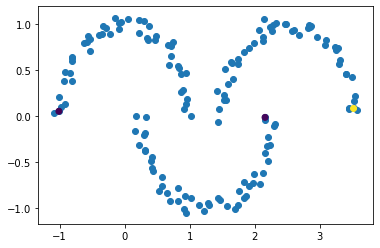

In [8]:
plt.scatter(P[:,0],P[:,1])
plt.scatter(P[ids,0],P[ids,1],c=ids)

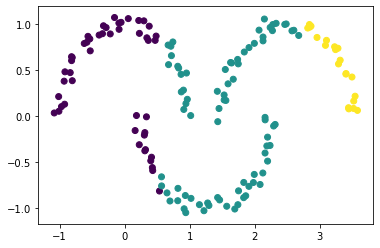

In [9]:
from scipy.spatial.distance import cdist

M = cdist(P[ids,:],P)

closest = np.argmin(M,axis=0)

plt.scatter(P[:,0],P[:,1],c=closest)

Construindo um grafo que connecta os pontos de forma apropriada, o Laplaciano propaga os rótulos através do grafo, ou seja, a propagação "enxerga" apenas as conexões do grafo durante o processo de propagação.

A idéia é criar um vetor para cada classe em um espação de dimensão $n$, onde $n$ é o número de vértices, sendo que vetor é igual a 1 nos vértices onde a classe é conhecida e zero nos demais vértices. Quando se projeta os vetores no espaço de autovetores associados aos menores autovalores da matriz Laplaciada, o que se faz é "propagar" o valor 1 pela vizinhança do grafo. A classe que alcança o maior valor no é atribuida aquele nó.

In [36]:
import connected_knn as cknn

A = cknn.connected_knn(P,extra_neighbors=3)
A = np.asarray(scp.sparse.csr_matrix.todense(A))
#print(A[0:2,:])

In [11]:
nozero = np.where(A != 0.0)
A[nozero] = np.exp(-(A[nozero]**2)/0.1)

In [ ]:
print(A[:2])

/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:563: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: 
The is_numlike function was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use isinstance(..., numbers.Number) instead.
  if cb.is_numlike(alpha):


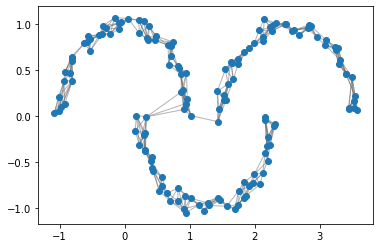

In [12]:
C = ntx.from_numpy_matrix(A)
ntx.draw_networkx_edges(C, pos=P, edge_color='dimgray',alpha=0.5)
plt.scatter(P[:,0],P[:,1])

In [37]:
L = np.diag(np.sum(A,axis=1).ravel()) - A
S, U = np.linalg.eigh(L)

In [38]:
labels = np.zeros((L.shape[0],len(ids)))
labels[ids,list(range(len(ids)))] = 1
n = 4
for i in range(len(ids)):
    vp = np.dot(U[:,:n].T,labels[:,i])
    labels[:,i] = np.dot(U[:,:n],vp[:n])

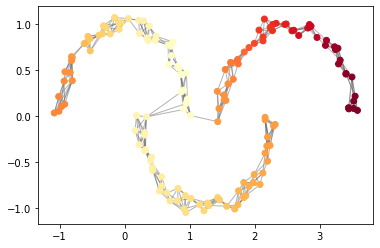

In [29]:
ntx.draw_networkx_edges(C, pos=P, edge_color='dimgray',alpha=0.5)
plt.scatter(P[:,0],P[:,1],c=labels[:,2],cmap='YlOrRd')

In [35]:
print(labels[:10,:])
print(labels_prop[:10])

[[-0.00510553 -0.0114677  -0.01066203]
 [-0.00459516 -0.01147727 -0.01148156]
 [-0.00468959 -0.01141614 -0.01145633]
 [-0.00453929 -0.01156424 -0.01151526]
 [-0.0040036  -0.01150874 -0.01156959]
 [-0.00426874 -0.0114393  -0.01155713]
 [-0.00300601 -0.01142195 -0.01164757]
 [-0.0026993  -0.0113303  -0.01158251]
 [-0.00108599 -0.011021   -0.01141164]
 [-0.00170731 -0.01116579 -0.0115055 ]]
[0 0 0 0 0 0 0 0 0 0]


/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:563: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
/anaconda3/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:611: MatplotlibDeprecationWarning: 
The is_numlike function was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use isinstance(..., numbers.Number) instead.
  if cb.is_numlike(alpha):


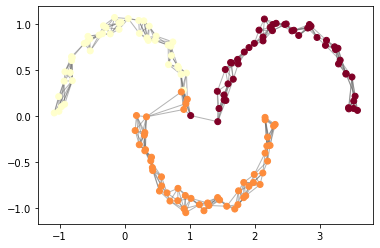

In [39]:
labels_prop = np.argmax(labels,axis=1)

ntx.draw_networkx_edges(C, pos=P, edge_color='dimgray',alpha=0.5)
plt.scatter(P[:,0],P[:,1],c=labels_prop,cmap='YlOrRd')

O problema com o método de propagação de rótulos com o Laplaciano é que:
1. O grafo precisa ser construído de forma apropriada
  - encontrar as arestas 
  - empregar pesos apropriados para as arestas
2. Decidir quantos autovetores utilizar
  - O número de autovetores deve ser próximo do número de classes